In [1]:
#Data Preprocessing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the Data
dataset_path = 'Dataset/dataset.csv'  

print("Loading the dataset...")
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print("\nFirst few rows of the dataset:")
print(df.head())

# 2. Handling Missing and Noisy Values
print("\nChecking for missing values...")
print(df.isnull().sum())

# Replace '?' with NaN in the entire dataset
df = df.replace('?', np.nan)

# Identify numerical columns (excluding 'target')
numerical_columns = df.select_dtypes(include=['number']).columns

# Separate numerical and non-numerical columns
df_numerical = df[numerical_columns].copy()

# Separate the 'target' column before imputation 
if 'target' in df_numerical.columns:
    y_target_original = df['target'].copy()  
    df_numerical = df_numerical.drop('target', axis=1)  
else:
    y_target_original = df['target'].copy() 

# Manual KNN Imputation 
print("\nApplying Manual KNN Imputation for numerical features...")
def manual_knn_impute(df_numeric, k=5):
    df_imputed = df_numeric.copy()
    missing_mask = df_imputed.isnull()
    
    for col in df_imputed.columns:
        for idx in df_imputed[missing_mask[col]].index:
            current_row = df_imputed.loc[idx].drop(col)
            other_rows = df_imputed[df_imputed[col].notna()]
            
            if other_rows.empty:
                df_imputed.loc[idx, col] = df_imputed[col].median()
                continue
            
            distances = np.sqrt(((other_rows.drop(columns=[col]) - current_row)**2).sum(axis=1))
            nearest_k_idx = distances.nsmallest(k).index
            df_imputed.loc[idx, col] = other_rows.loc[nearest_k_idx, col].mean()
    
    return df_imputed

df_imputed_knn = manual_knn_impute(df_numerical, k=5)

df_cleaned = df_imputed_knn.copy()
df_cleaned['target'] = y_target_original

# Remove Outlier(IQR)
print(f"\nNumber of rows before outlier removal: {df_cleaned.shape[0]}")

continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in continuous_features:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_cleaned = df_cleaned[
        (df_cleaned[col] >= lower_bound) & 
        (df_cleaned[col] <= upper_bound)
    ]
    print(f"Removed outliers in '{col}': kept {df_cleaned.shape[0]} rows")

print(f"Number of rows after IQR-based outlier removal: {df_cleaned.shape[0]}")

# Remove rows where 'target' is NaN
df_cleaned = df_cleaned.dropna(subset=['target'])
df_cleaned['target'] = df_cleaned['target'].astype(int)

# 3. Normalizing Numerical Features
X_features = df_cleaned.drop('target', axis=1)
y_target = df_cleaned['target']

# Min-Max Scaling (0-1) using numpy
print("\nApplying Min-Max Scaling...")
X_minmax_scaled = (X_features - X_features.min()) / (X_features.max() - X_features.min())
X_minmax_scaled = X_minmax_scaled.fillna(0)
print("Min-Max Scaled data (first 5 rows):")
print(X_minmax_scaled.head())  

# Z-Score Standardization (mean=0, std=1) using numpy
print("\nApplying Z-Score Standardization...")
X_standard_scaled = (X_features - X_features.mean()) / X_features.std()
X_standard_scaled = X_standard_scaled.fillna(0)  
print("Z-Score Standardized data (first 5 rows):")
print(X_standard_scaled.head()) 

# Robust Scaling (using median and IQR) using numpy
print("\nApplying Robust Scaling...")
median_vals = X_features.median()
iqr_vals = X_features.quantile(0.75) - X_features.quantile(0.25)
X_robust_scaled = (X_features - median_vals) / iqr_vals
X_robust_scaled = X_robust_scaled.fillna(0)  
print("Robust Scaled data (first 5 rows):")
print(X_robust_scaled.head()) 

# Combine normalized features with target
final_preprocessed_data = X_minmax_scaled.copy()
final_preprocessed_data['target'] = y_target

print("\nPreprocessing completed. Final preprocessed data shape:", final_preprocessed_data.shape)
print("\nFinal preprocessed data (first 5 rows):")
print(final_preprocessed_data.head())

# Save the final dataset
final_preprocessed_data.to_csv('Dataset/dataset_preprocessed.csv', index=False)
print("\nPreprocessed data saved to 'Dataset/dataset_preprocessed.csv'")

Loading the dataset...
Dataset loaded successfully.

First few rows of the dataset:
    age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  52.0    1   0     125.0  212.0    0        1    168.0      0      1.0   
1  53.0    1   0     140.0  203.0    1        0    155.0      1      3.1   
2  70.0    1   0     145.0  174.0    0        1    125.0      1      2.6   
3  61.0    1   0     148.0  203.0    0        1    161.0      0      0.0   
4  62.0    0   0     138.0  294.0    1        1    106.0      0      1.9   

   slope   ca  thal  target  
0      2  2.0   3.0       0  
1      0  0.0   3.0       0  
2      0  0.0   3.0       0  
3      2  1.0   3.0       0  
4      1  NaN   NaN       0  

Checking for missing values...
age         51
sex          0
cp           0
trestbps    51
chol        13
fbs          0
restecg      0
thalach     17
exang        0
oldpeak      1
slope        0
ca          51
thal        51
target       0
dtype: int64

Applying Manual KNN Imp

In [2]:
df = pd.read_csv('Dataset/dataset_preprocessed.csv')
print("Missing values in target:", df['target'].isnull().sum())

Missing values in target: 0


Histograms: 


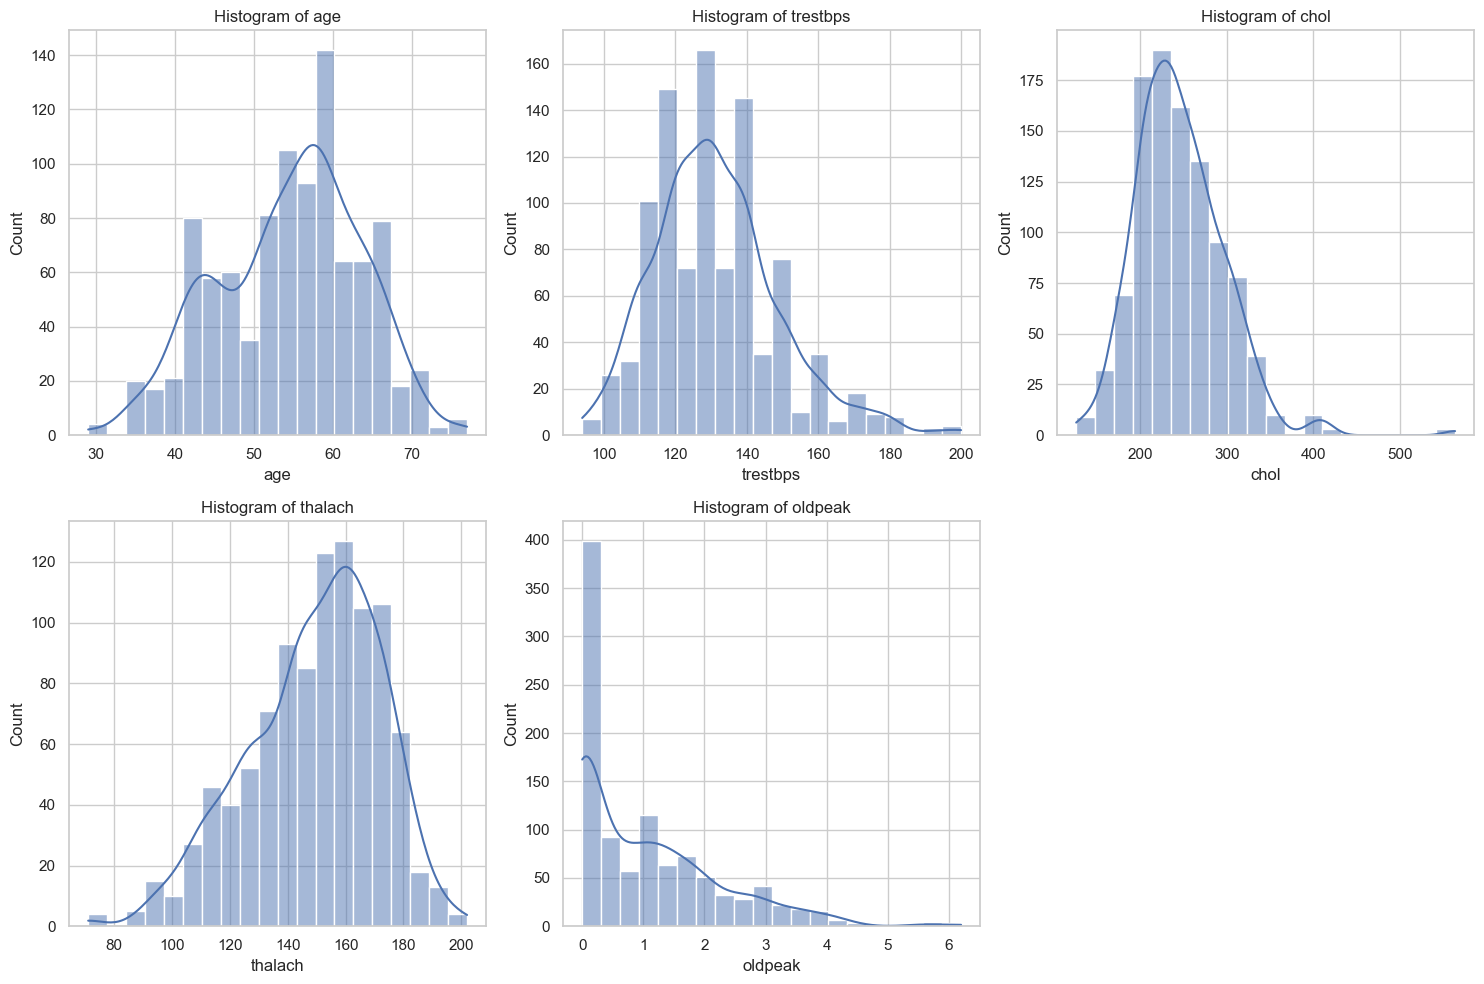

Boxplots: 


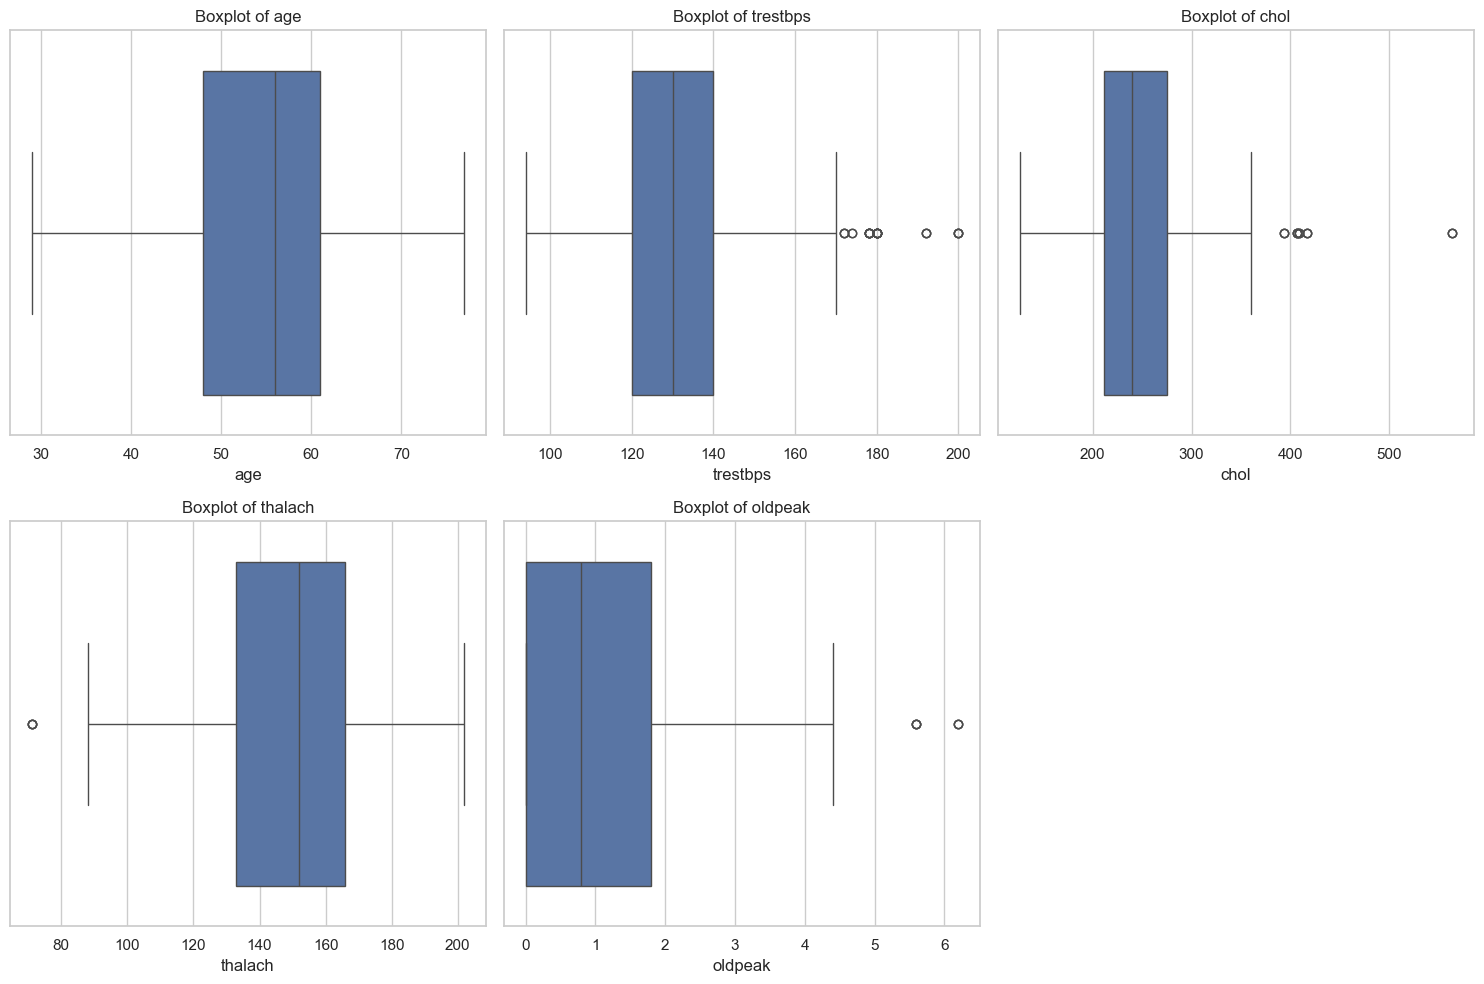

Q–Q Plots: 


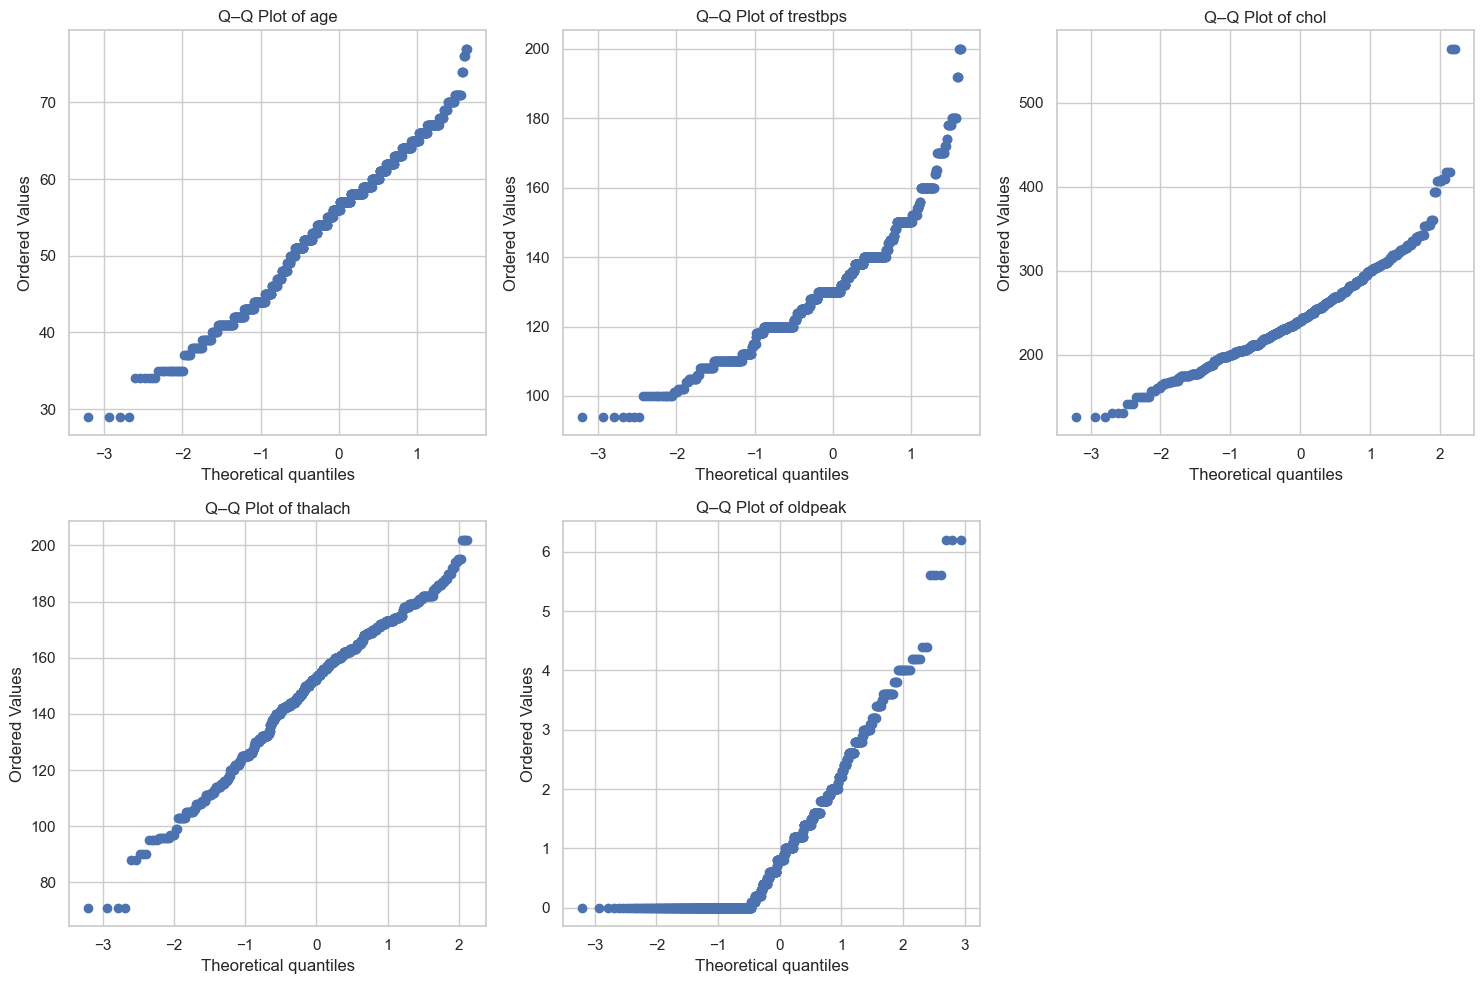

Correlation Matrix:  


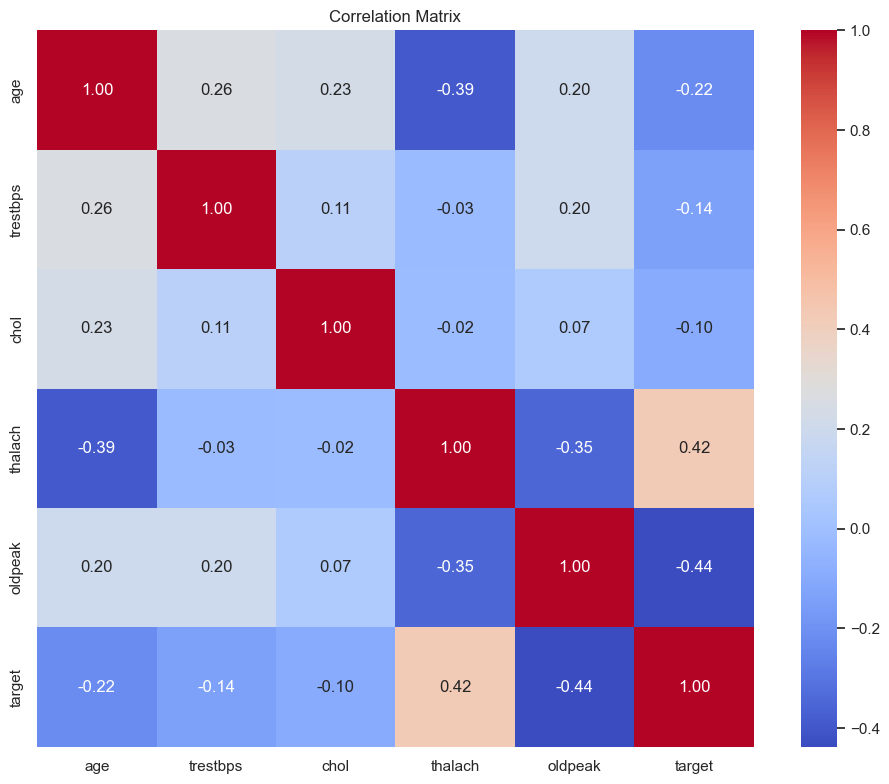

Pairplot: 


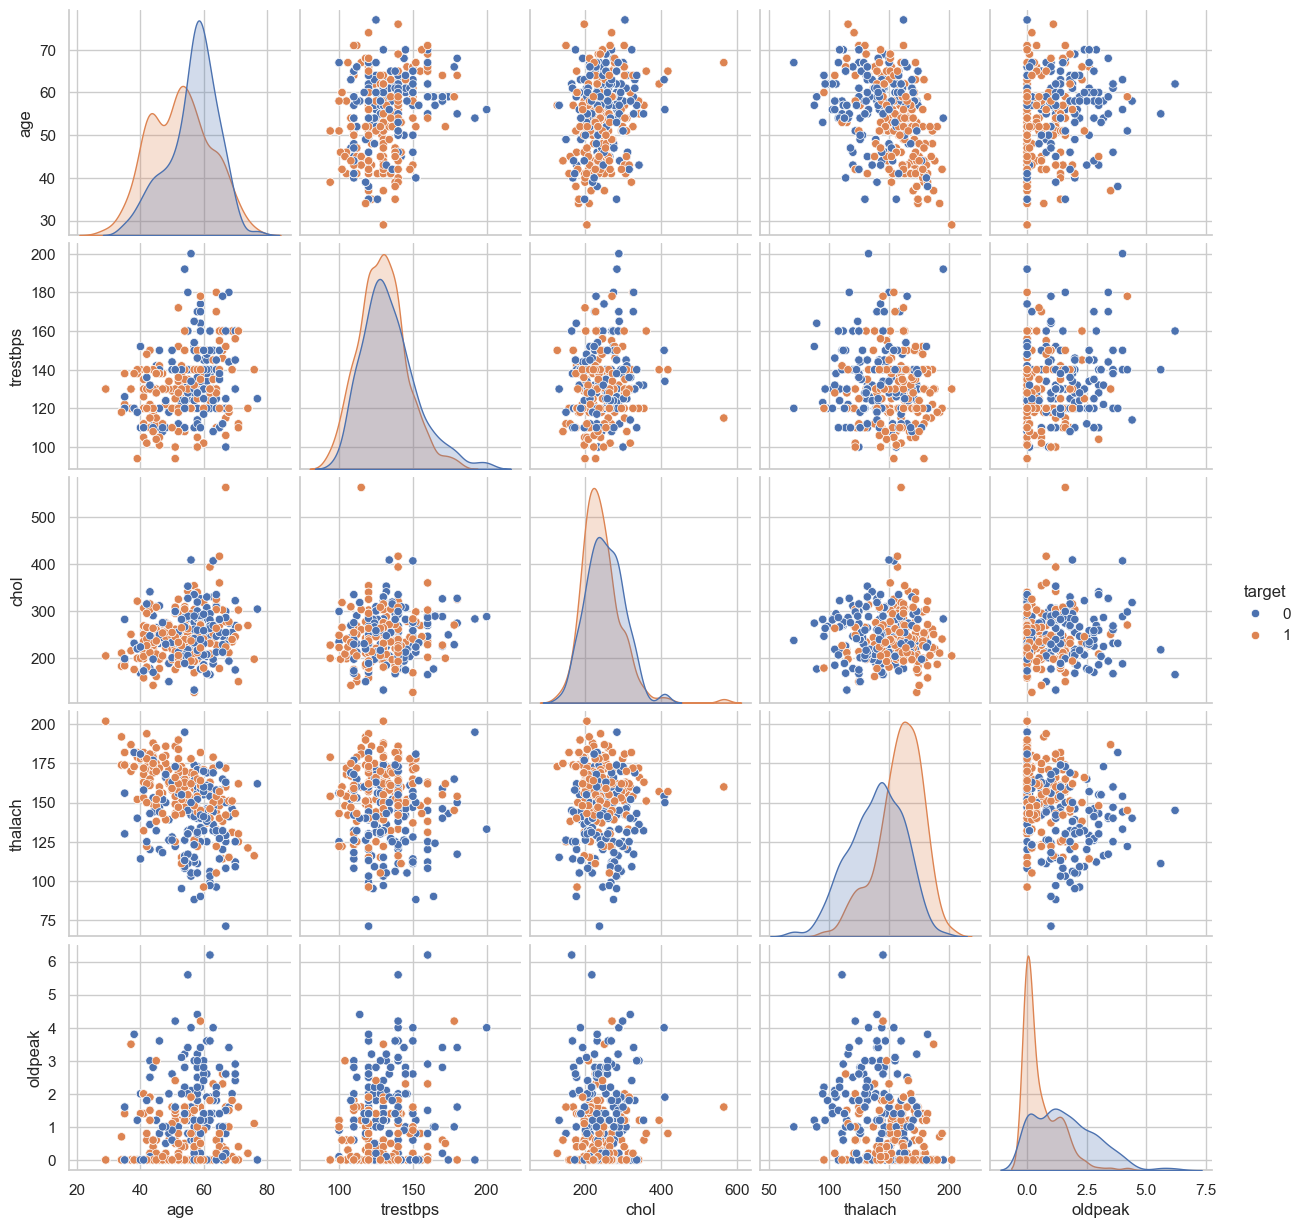

Count Plots: 


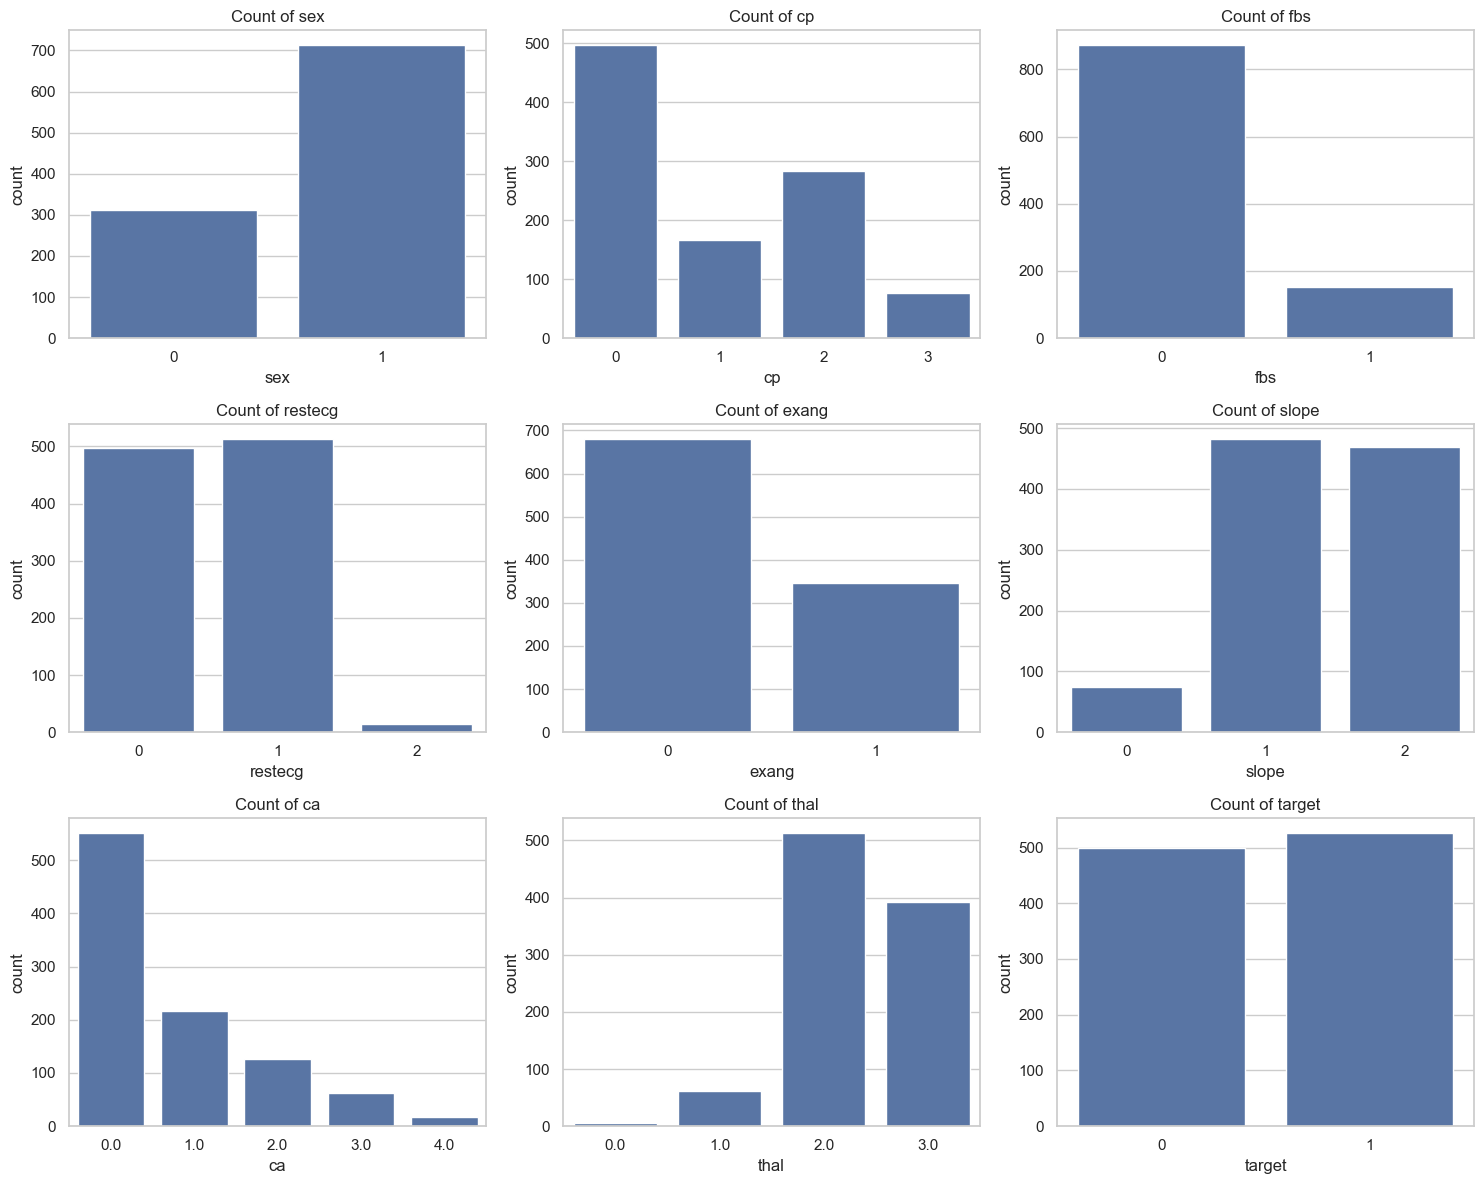

In [3]:
#Exploratory Data Analysis (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df_cleaned_for_eda = pd.read_csv('Dataset/dataset.csv')

# Continues features ( Histogram، boxplot، Q-Q، Correlation)
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# 1. Histograms
print("Histograms: ")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(numerical_features):
    sns.histplot(df_cleaned_for_eda[col], kde=True, ax=axes[i], bins=20) 
    axes[i].set_title(f'Histogram of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# 2. Boxplots
print("Boxplots: ")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(numerical_features):
    sns.boxplot(x=df_cleaned_for_eda[col], ax=axes[i]) 
    axes[i].set_title(f'Boxplot of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# 3. Q–Q Plots
print("Q–Q Plots: ")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(numerical_features):
    stats.probplot(df_cleaned_for_eda[col], dist="norm", plot=axes[i]) 
    axes[i].set_title(f'Q–Q Plot of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# 4. Correlation Matrix 
print("Correlation Matrix:  ")
corr_cols = numerical_features + ['target']
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned_for_eda[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True) 
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# 5. Pairplot 
print("Pairplot: ")
sns.pairplot(df_cleaned_for_eda[corr_cols], hue='target', diag_kind='kde') 
plt.show()

# 6. Count Plots 
print("Count Plots: ")
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for i, col in enumerate(categorical_features):
    sns.countplot(x=df_cleaned_for_eda[col], ax=axes[i]) 
    axes[i].set_title(f'Count of {col}')
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

Dataset shape: (968, 14)
Continuous features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Train set size: 774
Test set size: 194

→ Results for different K values (3, 5, 7):
   K  Accuracy  Precision  Recall  F1-Score
0  3      0.93       0.96    0.90      0.93
1  5      0.84       0.88    0.81      0.84
2  7      0.84       0.87    0.83      0.85

 Best K value: 3 with accuracy: 0.93


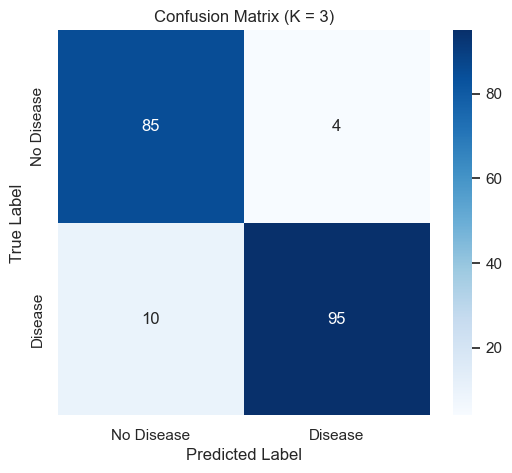

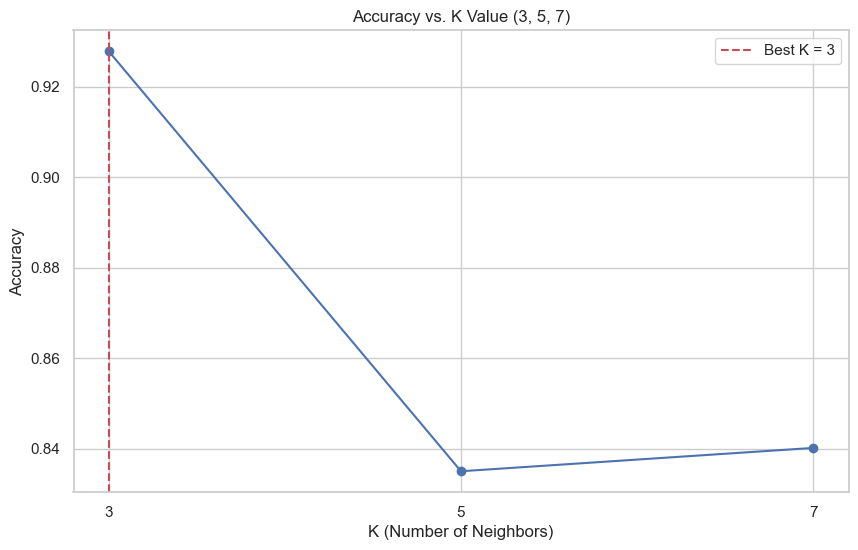


→ Final evaluation metrics (K = 3):
Accuracy: 0.93
Precision: 0.96
Recall: 0.90
F1-Score: 0.93


In [4]:
# Classification using K-Nearest Neighbors (KNN)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset/dataset_preprocessed.csv')

# Separate features (X) and target (y)
X = df.drop('target', axis=1).values  
y = df['target'].values

print(f"Dataset shape: {df.shape}")

# Identify feature indices for continuous and categorical features
feature_names = df.drop('target', axis=1).columns.tolist()
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = [f for f in feature_names if f not in continuous_features]

continuous_indices = [feature_names.index(f) for f in continuous_features]
categorical_indices = [feature_names.index(f) for f in categorical_features]

print(f"Continuous features: {continuous_features}")
print(f"Categorical features: {categorical_features}")

# 1. Split the dataset into 80% training and 20% testing (manually)
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Define manual KNN function with mixed distance
def knn_predict_mixed(X_train, y_train, X_test_instance, k):
    # Euclidean distance for continuous features
    if continuous_indices:
        diff_cont = X_train[:, continuous_indices] - X_test_instance[continuous_indices]
        dist_cont = np.sqrt(np.sum(diff_cont**2, axis=1))
        # Normalize by number of features to balance influence
        dist_cont = dist_cont / len(continuous_indices)
    else:
        dist_cont = 0

    # Hamming distance for categorical features
    if categorical_indices:
        diff_cat = X_train[:, categorical_indices] != X_test_instance[categorical_indices]
        dist_cat = np.sum(diff_cat, axis=1)  # Number of mismatched features
        # Normalize by number of features to balance influence
        dist_cat = dist_cat / len(categorical_indices)
    else:
        dist_cat = 0

    # Combine distances with not equal weights 
    total_distance = 0.60 * dist_cont + 0.40 * dist_cat

    # Find the k nearest neighbors
    k_indices = np.argsort(total_distance)[:k]
    k_labels = y_train[k_indices]
    
    # Majority vote
    prediction = np.bincount(k_labels.astype(int)).argmax()
    
    return prediction

# Define evaluation metrics function (manual)
def calculate_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return accuracy, precision, recall, f1

# 2. Test different K values (3, 5, 7)
k_values = [3, 5, 7]
results = []

for k in k_values:
    y_pred_list = []
    for x_test in X_test:
        pred = knn_predict_mixed(X_train, y_train, x_test, k)
        y_pred_list.append(pred)
    
    y_pred = np.array(y_pred_list)
    
    acc, prec, rec, f1 = calculate_metrics(y_test, y_pred)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)
print("\n→ Results for different K values (3, 5, 7):")
print(results_df.round(2))

# 3. Find the best K
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
best_acc = results_df.loc[results_df['Accuracy'].idxmax(), 'Accuracy']
print(f"\n Best K value: {int(best_k)} with accuracy: {best_acc:.2f}")

# Run the final model with the best K
y_pred_final_list = []
for x_test in X_test:
    pred = knn_predict_mixed(X_train, y_train, x_test, int(best_k))
    y_pred_final_list.append(pred)

y_pred_final = np.array(y_pred_final_list)

# 4. Display Confusion Matrix (manual)
tp = np.sum((y_test == 1) & (y_pred_final == 1))
tn = np.sum((y_test == 0) & (y_pred_final == 0))
fp = np.sum((y_test == 0) & (y_pred_final == 1))
fn = np.sum((y_test == 1) & (y_pred_final == 0))

cm = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix (K = {int(best_k)})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Plot accuracy vs. K
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', linestyle='-', color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K = {int(best_k)}')
plt.title('Accuracy vs. K Value (3, 5, 7)')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

# 6. Display final metrics
final_acc, final_prec, final_rec, final_f1 = calculate_metrics(y_test, y_pred_final)
final_metrics = {
    'Accuracy': final_acc,
    'Precision': final_prec,
    'Recall': final_rec,
    'F1-Score': final_f1
}

print("\n→ Final evaluation metrics (K = {}):".format(int(best_k)))
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.2f}")